In [2]:
import pandas as pd

df = pd.read_csv("dataframes/tripadvisor.csv")
df = df.drop(columns=["nome"], errors="ignore")
df

,cidade_e_estado,contribuicoes,nota,titulo,em_companhia_de,review,imagens,nota_custo,nota_atendimento,nota_comida,nota_ambiente,is_parceria_patrocinada,data_postagem,title_len,review_len,day_of_month,day_of_week,month,year
0,"Barueri, SP",41,1,Aniversário de casamento arruinado pelo péssim...,Casal,Fomos ao restaurante para comemorar nosso aniv...,0,NaN,NaN,NaN,NaN,False,2025-12-29,71,1595,29,monday,december,2025
1,"Rio de Janeiro, RJ",2,3,Lugar agradável mas nada excepcional.,Amigos,Ambiente ok. Freitas atencioso e atento. No ma...,0,NaN,NaN,NaN,NaN,False,2025-10-18,37,129,18,saturday,october,2025
2,"Recife, PE",541,5,Excelente restaurante do chef Jacquin,Família,"Excelente restaurante do chef Jacquin, da entr...",3,NaN,NaN,NaN,NaN,False,2025-09-20,37,200,20,saturday,september,2025
3,"São Roque, SP",22,5,Excelente local.,Família,O restaurante tem uma decoração muito bonita.\...,0,5.0,5.0,5.0,5.0,False,2025-09-18,16,268,18,thursday,september,2025
4,"Recife, PE",140,5,Ótima experiência,Família,"ambiente agradável e bem decorado, comida muit...",0,NaN,NaN,NaN,NaN,False,2025-09-16,17,260,16,tuesday,september,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,NaN,50,4,Italiano francês,Família,"Gostamos muito do restaurante, ponto alto para...",1,NaN,NaN,NaN,NaN,False,2025-06-13,16,836,13,friday,june,2025
71,"Itapetinga, BA",21,5,LVTETIA RESTAURANTE DO JACQUIN QUE SURPREENDE ...,Amigos,Comida perfeita e preço justo. Fui a este rest...,6,NaN,NaN,NaN,NaN,False,2025-04-14,59,379,14,monday,april,2025
72,"Porto Alegre, RS",229,5,Imperdível,Família,"Restaurante italiano do chef Erik Jacquin, ped...",0,4.0,5.0,5.0,5.0,False,2025-04-07,10,194,7,monday,april,2025
73,"São Paulo, SP",984,5,Boa pedida,Casal,Fui de executivo e saí muito satisfeito. Porçõ...,1,NaN,NaN,NaN,NaN,False,2024-10-27,10,191,27,sunday,october,2024


In [3]:
# Analysis setup (helpers + derived columns)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

import re

# Make DEFAULT_COLOR the default for Matplotlib/Seaborn plots, unless a plot explicitly sets its own colors
from cycler import cycler

DEFAULT_COLOR = "#00852F"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

plt.rcParams["axes.prop_cycle"] = cycler(color=[DEFAULT_COLOR])
sns.set_palette([DEFAULT_COLOR])


def _safe_len(value) -> float:
    if pd.isna(value):
        return np.nan
    return float(len(str(value).strip()))


def _images_count(value) -> int:
    if pd.isna(value):
        return 0
    # Common cases: already numeric, list-like, or a string with separators
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, float) and float(value).is_integer():
        return int(value)
    if isinstance(value, (list, tuple, set)):
        return int(len(value))

    text = str(value).strip()
    if text == "":
        return 0

    # If it looks like a single URL/path, count as 1
    if ";" not in text and "," not in text and "|" not in text:
        return 1

    parts = [p.strip() for p in re.split(r"[;,|]", text) if p.strip()]
    return int(len(parts))


def _extract_state(value):
    if pd.isna(value):
        return np.nan
    m = re.search(r",\s*([A-Z]{2})\s*$", str(value).strip())
    return m.group(1) if m else np.nan

def grade_red_to_green(grade, missing="#BDBDBD") -> str:
    """
    Piecewise mapping:
      grade=1 -> red    (#ff0000)
      grade=3 -> yellow (##FBBC04)
      grade=5 -> green  (#489160)

    grade=2 is interpolated between 1 and 3
    grade=4 is interpolated between 3 and 5
    """
    if pd.isna(grade):
        return missing

    g = float(grade)
    g = max(1.0, min(5.0, g))

    # Anchor colors
    r1, g1, b1 = 0xFF, 0x00, 0x00  # grade 1: #ff0000
    r3, g3, b3 = 0xFB, 0xBC, 0x04  # grade 3: #FBBC04
    r5, g5, b5 = 0x48, 0x91, 0x60  # grade 5: #489160

    if g <= 3.0:
        # Interpolate 1..3
        t = (g - 1.0) / 2.0  # 0..1
        r0, g0, b0 = r1, g1, b1
        r1_, g1_, b1_ = r3, g3, b3
    else:
        # Interpolate 3..5
        t = (g - 3.0) / 2.0  # 0..1
        r0, g0, b0 = r3, g3, b3
        r1_, g1_, b1_ = r5, g5, b5

    r = int(round(r0 + (r1_ - r0) * t))
    gr = int(round(g0 + (g1_ - g0) * t))
    b = int(round(b0 + (b1_ - b0) * t))

    return f"#{r:02x}{gr:02x}{b:02x}"

# Ensure expected derived columns exist (your CSV already has these, but keep robust)
if "title_len" not in df.columns:
    df["title_len"] = df.get("titulo", pd.Series([np.nan] * len(df))).apply(_safe_len)

if "review_len" not in df.columns:
    df["review_len"] = df.get("review", pd.Series([np.nan] * len(df))).apply(_safe_len)

if "images_count" not in df.columns:
    df["images_count"] = df.get("imagens", pd.Series([np.nan] * len(df))).apply(_images_count)

if "has_image" not in df.columns:
    df["has_image"] = df["images_count"].fillna(0).astype(int) > 0

if "state" not in df.columns:
    df["state"] = df.get("cidade_e_estado", pd.Series([np.nan] * len(df))).apply(_extract_state)

# Normalize numeric-like columns (safe coercion)
for col in [
    "nota",
    "contribuicoes",
    "nota_custo",
    "nota_atendimento",
    "nota_comida",
    "nota_ambiente",
    "title_len",
    "review_len",
    "images_count",
    "day_of_month",
    "day_of_week",
    "month",
    "year",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "is_parceria_patrocinada" in df.columns:
    # Coerce to boolean-ish; keep original column but add numeric version for correlations
    df["is_parceria_patrocinada_int"] = df["is_parceria_patrocinada"].astype(bool).astype(int)

# Date-derived columns: if missing OR entirely null, derive from data_postagem
if "data_postagem" in df.columns:
    dt = pd.to_datetime(df["data_postagem"], errors="coerce")

    if "year" not in df.columns or df["year"].isna().all():
        df["year"] = dt.dt.year

    if "month" not in df.columns or df["month"].isna().all():
        df["month"] = dt.dt.month

    if "day_of_month" not in df.columns or df["day_of_month"].isna().all():
        df["day_of_month"] = dt.dt.day

    if "day_of_week" not in df.columns or df["day_of_week"].isna().all():
        df["day_of_week"] = dt.dt.dayofweek

# Fix common indexing variants
if "month" in df.columns:
    # If month is 0..11, shift to 1..12
    if df["month"].dropna().between(0, 11).all() and not df["month"].dropna().between(1, 12).all():
        df["month"] = df["month"] + 1

if "day_of_week" in df.columns:
    # If day_of_week is 1..7, shift to 0..6
    if df["day_of_week"].dropna().between(1, 7).all() and not df["day_of_week"].dropna().between(0, 6).all():
        df["day_of_week"] = df["day_of_week"] - 1

# A readable weekday label for charts (0=Mon)
if "day_of_week" in df.columns:
    labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    df["day_of_week_label"] = pd.to_numeric(df["day_of_week"], errors="coerce").map(
        lambda x: labels[int(x)] if pd.notna(x) and 0 <= int(x) <= 6 else np.nan
    )


# Review Dataset — Statistical Analysis

This notebook explores basic and advanced descriptive statistics for the restaurant reviews in `df`.

The analysis is grouped from the most generic (dataset-level summaries) to the most specific (text analytics and correlations).

## 1) Dataset Overview
We'll start with a quick dataset snapshot: size, time coverage, average score, and how common images are.

In [3]:
# Display: number of reviews, years present, average grade, and reviews with images
n_reviews = len(df)
years = sorted([int(y) for y in pd.Series(df.get("year")).dropna().unique()]) if "year" in df.columns else []
avg_grade = df["nota"].mean() if "nota" in df.columns else np.nan

# Count reviews that have at least one image
if "has_image" in df.columns:
    n_with_image = int(df["has_image"].sum())
else:
    # fallback if has_image wasn't created
    n_with_image = int((df.get("imagens").notna()).sum()) if "imagens" in df.columns else 0

summary = pd.DataFrame(
    {
        "metric": [
            "reviews",
            "years appearing",
            "average grade (nota)",
            "reviews with image",
            "% with image",
        ],
        "value": [
            n_reviews,
            ", ".join(map(str, years)) if years else "(no year data)",
            avg_grade,
            n_with_image,
            (n_with_image / n_reviews * 100) if n_reviews else np.nan,
        ],
    }
)

display(summary)

,metric,value
0,reviews,75
1,years appearing,"2022, 2023, 2024, 2025"
2,average grade (nota),3.813333
3,reviews with image,33
4,% with image,44.0


## 2) Geography
Next we aggregate reviews by Brazilian state, extracted from `cidade_e_estado` (the last two uppercase letters after a comma).

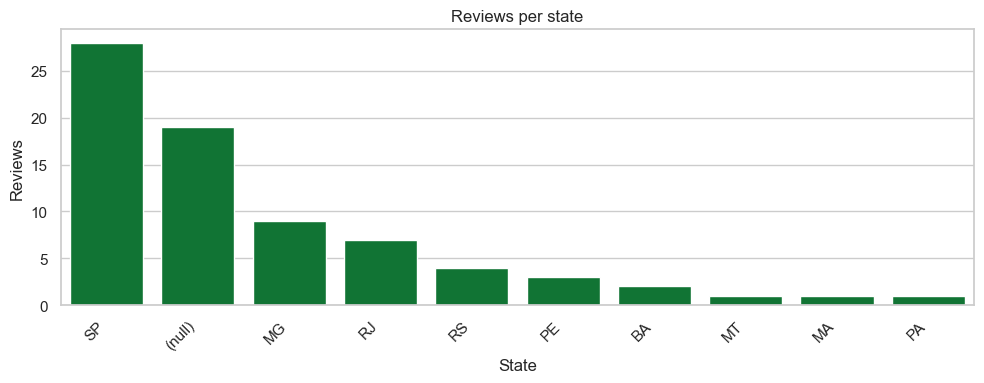

,reviews
state,
SP,28
(null),19
MG,9
RJ,7
RS,4
PE,3
BA,2
MT,1
MA,1


In [4]:
# Bar graph: reviews per state + display
state_counts = df["state"].fillna("(null)").value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=state_counts.index, y=state_counts.values)
ax.set_title("Reviews per state")
ax.set_xlabel("State")
ax.set_ylabel("Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(state_counts.rename("reviews").to_frame())

## 3) Rating Distributions
Here we look at overall review grade distribution (`nota`) and the presence/distribution of the more detailed sub-scores (`nota_custo`, `nota_atendimento`, `nota_comida`, `nota_ambiente`).

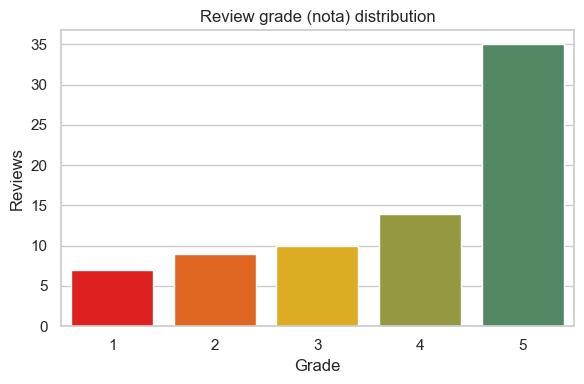

,count,pct_of_dataset
nota,,
1,7,9.33
2,9,12.00
3,10,13.33
4,14,18.67
5,35,46.67


In [5]:
# Bar graph: count of each review grade (1..5) + display with percentages
levels = [1, 2, 3, 4, 5]

nota_counts = df["nota"].value_counts(dropna=False).reindex(levels, fill_value=0)
nota_pct = (nota_counts / len(df) * 100).round(2)

plot_df = nota_counts.rename_axis("grade").reset_index(name="reviews")
# Seaborn treats categorical labels as strings in some cases; keep palette keys consistent
plot_df["grade"] = plot_df["grade"].astype(int).astype(str)
levels_str = [str(g) for g in levels]

palette = {str(g): grade_red_to_green(g) for g in levels}

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=plot_df,
    x="grade",
    y="reviews",
    order=levels_str,
    # Seaborn >=0.13 warns when passing `palette` without `hue`
    hue="grade",
    hue_order=levels_str,
    palette=palette,
    legend=False,
    dodge=False,
 )
ax.set_title("Review grade (nota) distribution")
ax.set_xlabel("Grade")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

nota_summary = pd.DataFrame({"count": nota_counts.astype(int), "pct_of_dataset": nota_pct})
display(nota_summary)

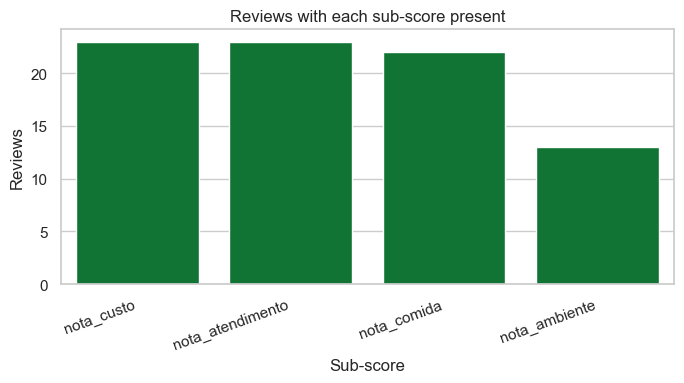

,reviews_with_value,pct_of_dataset
nota_custo,23,30.67
nota_atendimento,23,30.67
nota_comida,22,29.33
nota_ambiente,13,17.33


In [6]:
# Bar graph: how many reviews have each specific sub-score present + display
subscore_cols = ["nota_custo", "nota_atendimento", "nota_comida", "nota_ambiente"]
subscore_present = {col: int(df[col].notna().sum()) for col in subscore_cols if col in df.columns}
subscore_present = pd.Series(subscore_present).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=subscore_present.index, y=subscore_present.values)
ax.set_title("Reviews with each sub-score present")
ax.set_xlabel("Sub-score")
ax.set_ylabel("Reviews")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

n_reviews = len(df)
subscore_present_df = pd.DataFrame(
    {
        "reviews_with_value": subscore_present.astype(int),
        "pct_of_dataset": (subscore_present / n_reviews * 100).round(2) if n_reviews else np.nan,
    }
)

display(subscore_present_df)

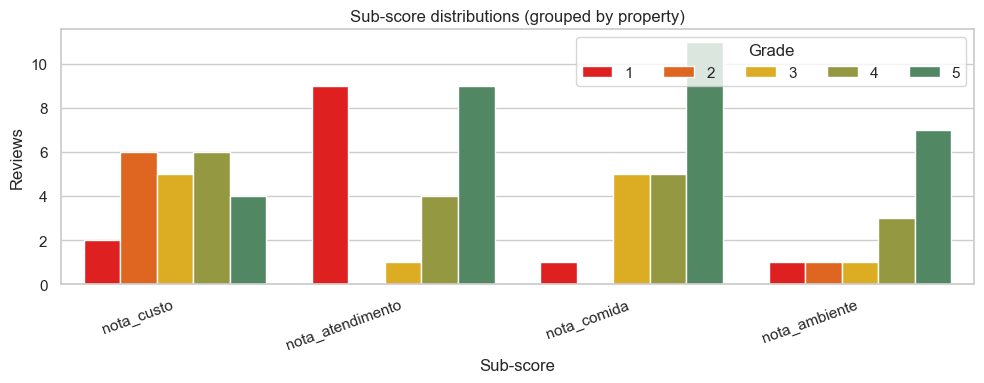

nota_custo (non-null reviews: 23)


,count,pct_of_non_null
grade,,
1,2,8.70
2,6,26.09
3,5,21.74
4,6,26.09
5,4,17.39


nota_atendimento (non-null reviews: 23)


,count,pct_of_non_null
grade,,
1,9,39.13
2,0,0.00
3,1,4.35
4,4,17.39
5,9,39.13


nota_comida (non-null reviews: 22)


,count,pct_of_non_null
grade,,
1,1,4.55
2,0,0.00
3,5,22.73
4,5,22.73
5,11,50.00


nota_ambiente (non-null reviews: 13)


,count,pct_of_non_null
grade,,
1,1,7.69
2,1,7.69
3,1,7.69
4,3,23.08
5,7,53.85


In [7]:
# Grouped bar graph: for each sub-score (property), compare grade counts (1..5) + display
subscore_cols = [c for c in ["nota_custo", "nota_atendimento", "nota_comida", "nota_ambiente"] if c in df.columns]
levels = [1, 2, 3, 4, 5]

# Build counts as: rows=property, cols=grade (counts only among non-null values)
counts_by_prop = {}
n_non_null_by_prop = {}
for col in subscore_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s.isin(levels)]
    counts = s.value_counts().reindex(levels, fill_value=0)
    counts_by_prop[col] = counts
    n_non_null_by_prop[col] = int(counts.sum())

counts_by_prop_df = pd.DataFrame(counts_by_prop, index=levels).T  # rows=property, cols=grade

# Long form for seaborn
plot_df = (
    counts_by_prop_df.reset_index()
    .rename(columns={"index": "property"})
    .melt(id_vars="property", var_name="grade", value_name="reviews")
)

# Use string hue labels so palette mapping is stable
plot_df["grade"] = plot_df["grade"].astype(int).astype(str)
levels_str = [str(g) for g in levels]
palette = {str(g): grade_red_to_green(g) for g in levels}

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=plot_df,
    x="property",
    y="reviews",
    hue="grade",
    order=subscore_cols,
    hue_order=levels_str,
    palette=palette,
)
ax.set_title("Sub-score distributions (grouped by property)")
ax.set_xlabel("Sub-score")
ax.set_ylabel("Reviews")
plt.xticks(rotation=20, ha="right")
ax.legend(title="Grade", ncols=5, loc="upper right")
plt.tight_layout()
plt.show()

# One display per property: count + % among reviews where the property is present (non-null)
for col in subscore_cols:
    denom = n_non_null_by_prop.get(col, 0)
    counts = counts_by_prop[col].astype(int)

    pct = (counts / denom * 100).round(2) if denom else (counts * np.nan)
    prop_df = pd.DataFrame(
        {
            "count": counts,
            "pct_of_non_null": pct,
        }
    )
    prop_df.index.name = "grade"

    print(f"{col} (non-null reviews: {denom})")
    display(prop_df)

## 4) Categories & Sponsorship
These fields help describe the context of the review (e.g., who the reviewer was with) and whether the review is marked as sponsored.

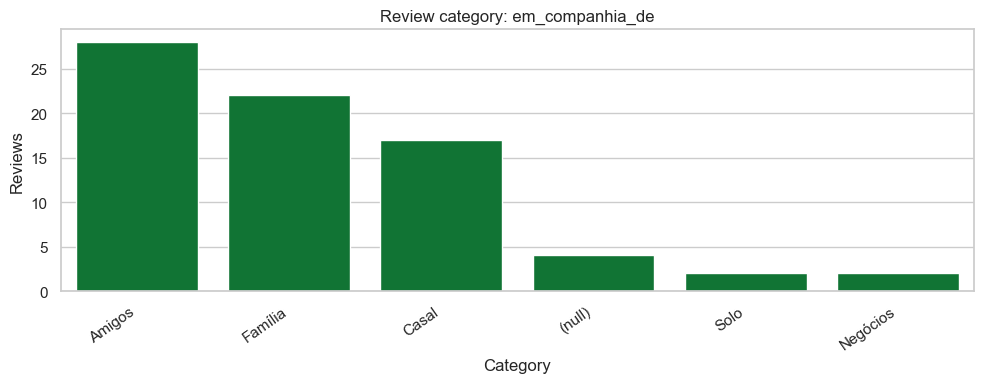

,count,pct_of_dataset
em_companhia_de,,
Amigos,28,37.33
Família,22,29.33
Casal,17,22.67
(null),4,5.33
Solo,2,2.67
Negócios,2,2.67


In [8]:
# Bar graph: em_companhia_de categories (including null) + display with percentages
comp_col = "em_companhia_de"
comp = df[comp_col].fillna("(null)")
comp_counts = comp.value_counts(dropna=False)
comp_pct = (comp_counts / len(df) * 100).round(2)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=comp_counts.index.astype(str), y=comp_counts.values)
ax.set_title("Review category: em_companhia_de")
ax.set_xlabel("Category")
ax.set_ylabel("Reviews")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": comp_counts.astype(int), "pct_of_dataset": comp_pct}))

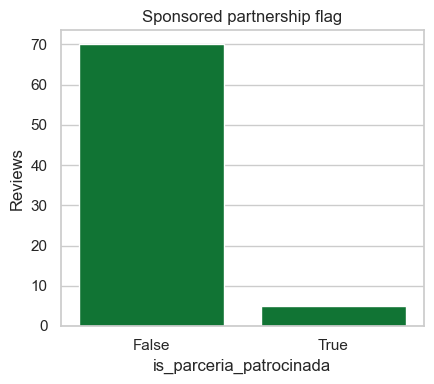

,count,pct_of_dataset
is_parceria_patrocinada,,
False,70,93.33
True,5,6.67


In [9]:
# Bar graph: is_parceria_patrocinada (True/False) + display with percentages
sponsor = df["is_parceria_patrocinada"].astype(bool)
sponsor_counts = sponsor.value_counts().rename(index={True: "True", False: "False"})
sponsor_pct = (sponsor_counts / len(df) * 100).round(2)

plt.figure(figsize=(4.5, 4))
ax = sns.barplot(x=sponsor_counts.index.astype(str), y=sponsor_counts.values)
ax.set_title("Sponsored partnership flag")
ax.set_xlabel("is_parceria_patrocinada")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": sponsor_counts.astype(int), "pct_of_dataset": sponsor_pct}))

## 5) Contributions
`contribuicoes` is a proxy for reviewer activity/engagement; we’ll inspect its distribution.

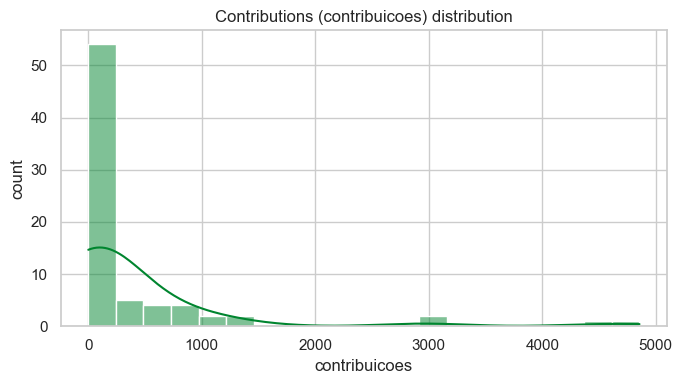

,count,min,p25,median,mean,p75,max
0,75,1,14.0,71.0,408.293333,369.0,4856


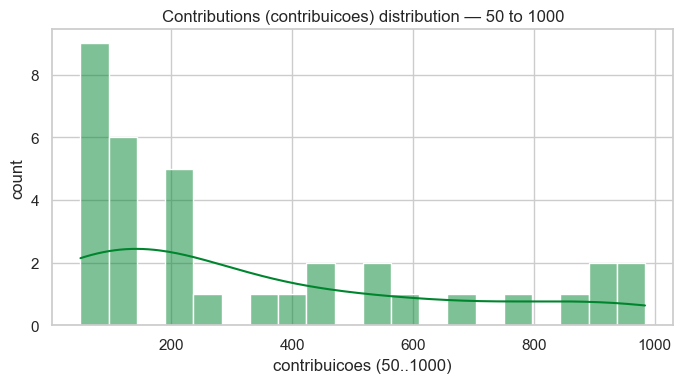

,count,min,p25,median,mean,p75,max,excluded_<50,excluded_>1000,pct_included
0,35,50,98.0,229.0,348.657143,542.0,984,34,6,46.67


In [21]:
# Histogram: contribuicoes + display
vals = df["contribuicoes"].dropna()

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, bins=20, kde=True)
ax.set_title("Contributions (contribuicoes) distribution")
ax.set_xlabel("contribuicoes")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

contrib_summary = pd.DataFrame(
    {
        "count": [int(vals.shape[0])],
        "min": [vals.min() if not vals.empty else np.nan],
        "p25": [vals.quantile(0.25) if not vals.empty else np.nan],
        "median": [vals.median() if not vals.empty else np.nan],
        "mean": [vals.mean() if not vals.empty else np.nan],
        "p75": [vals.quantile(0.75) if not vals.empty else np.nan],
        "max": [vals.max() if not vals.empty else np.nan],
    }
)

display(contrib_summary)

# Histogram + display: contribuicoes (50..1000)
mask_50_1000 = df["contribuicoes"].notna() & df["contribuicoes"].between(50, 1000, inclusive="both")
vals_50_1000 = df.loc[mask_50_1000, "contribuicoes"]

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals_50_1000, bins=20, kde=True)
ax.set_title("Contributions (contribuicoes) distribution — 50 to 1000")
ax.set_xlabel("contribuicoes (50..1000)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

contrib_summary_50_1000 = pd.DataFrame(
    {
        "count": [int(vals_50_1000.shape[0])],
        "min": [vals_50_1000.min() if not vals_50_1000.empty else np.nan],
        "p25": [vals_50_1000.quantile(0.25) if not vals_50_1000.empty else np.nan],
        "median": [vals_50_1000.median() if not vals_50_1000.empty else np.nan],
        "mean": [vals_50_1000.mean() if not vals_50_1000.empty else np.nan],
        "p75": [vals_50_1000.quantile(0.75) if not vals_50_1000.empty else np.nan],
        "max": [vals_50_1000.max() if not vals_50_1000.empty else np.nan],
        "excluded_<50": [int((df["contribuicoes"] < 50).sum())],
        "excluded_>1000": [int((df["contribuicoes"] > 1000).sum())],
        "pct_included": [round((vals_50_1000.shape[0] / len(df) * 100), 2) if len(df) else np.nan],
    }
)

display(contrib_summary_50_1000)

## 6) Time Patterns
We use the extracted fields (`year`, `month`, `day_of_week`, `day_of_month`) to see when reviews were posted.

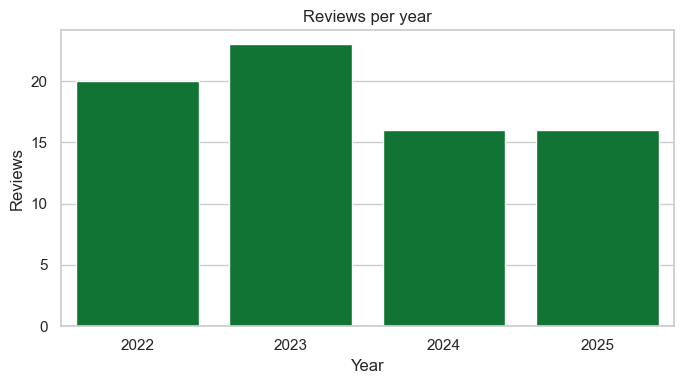

,count,pct_of_dataset
year,,
2022,20,26.67
2023,23,30.67
2024,16,21.33
2025,16,21.33


In [11]:
# Bar graph: year posting + display (with % of dataset)
year_counts = df["year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=year_counts.index.astype(str), y=year_counts.values)
ax.set_title("Reviews per year")
ax.set_xlabel("Year")
ax.set_ylabel("Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

year_summary = pd.DataFrame(
    {
        "count": year_counts.astype(int),
        "pct_of_dataset": (year_counts / len(df) * 100).round(2),
    }
)
year_summary.index.name = "year"
display(year_summary)

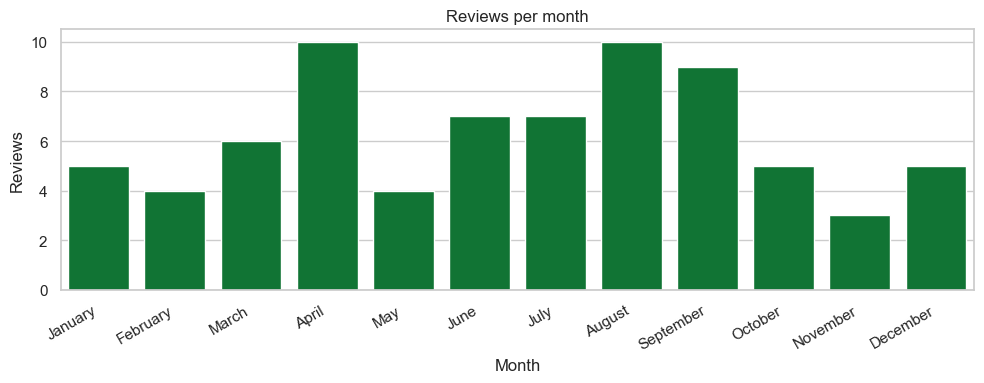

,reviews,pct_of_dataset
month,,
January,5,6.67
February,4,5.33
March,6,8.00
April,10,13.33
May,4,5.33
June,7,9.33
July,7,9.33
August,10,13.33
September,9,12.00


In [24]:
# Bar graph: month posting + display (with % of dataset) — use full month names
months = list(range(1, 13))

month_counts = (
    df["month"]
    .dropna()
    .astype(int)
    .value_counts()
    .reindex(months, fill_value=0)
    .sort_index()
)

# Map 1..12 -> "January".. "December" (locale depends on your environment)
month_labels = pd.to_datetime(pd.Series(month_counts.index.astype(str)), format="%m").dt.strftime("%B")
month_labels = month_labels.tolist()

# Plot
plt.figure(figsize=(10, 4))
ax = sns.barplot(x=month_labels, y=month_counts.values, order=month_labels)
ax.set_title("Reviews per month")
ax.set_xlabel("Month")
ax.set_ylabel("Reviews")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Display (fix index-alignment causing NaNs)
n_reviews_total = len(df)

pct_vals = ((month_counts / n_reviews_total) * 100).round(2).values

month_summary = pd.DataFrame(
    {
        "reviews": month_counts.astype(int).values,
        "pct_of_dataset": pct_vals,
    },
    index=month_labels,
)
month_summary.index.name = "month"
display(month_summary)

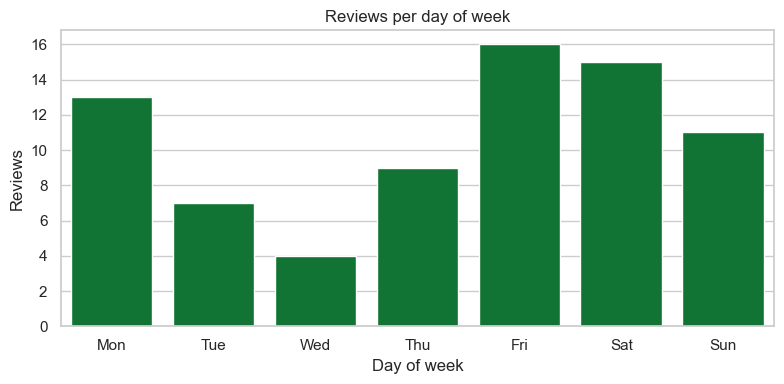

,reviews,pct_of_dataset
day_of_week_label,,
Mon,13,17.33
Tue,7,9.33
Wed,4,5.33
Thu,9,12.00
Fri,16,21.33
Sat,15,20.00
Sun,11,14.67


In [13]:
# Bar graph: day of week posting + display
# Prefer labels when available
if "day_of_week_label" in df.columns:
    dow = df["day_of_week_label"].fillna("(null)")
    order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", "(null)"]
    dow_counts = dow.value_counts().reindex([x for x in order if x in dow.value_counts().index], fill_value=0)
else:
    dow_counts = df["day_of_week"].fillna(-1).astype(int).value_counts().sort_index()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=dow_counts.index.astype(str), y=dow_counts.values)
ax.set_title("Reviews per day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

dow_summary = pd.DataFrame(
    {
        "reviews": dow_counts.astype(int),
        "pct_of_dataset": (dow_counts / len(df) * 100).round(2) if len(df) else np.nan,
    }
)
display(dow_summary)

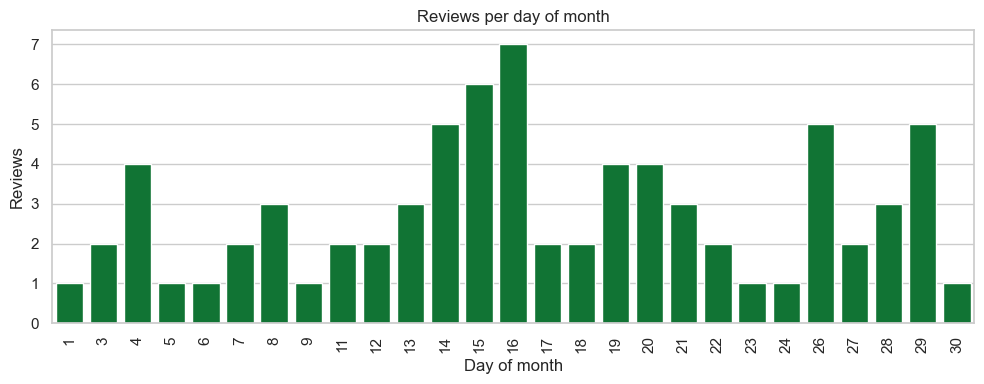

,reviews
day_of_month,
1,1
3,2
4,4
5,1
6,1
7,2
8,3
9,1
11,2


In [14]:
# Bar graph: day of month posting + display
dom_counts = df["day_of_month"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=dom_counts.index.astype(str), y=dom_counts.values)
ax.set_title("Reviews per day of month")
ax.set_xlabel("Day of month")
ax.set_ylabel("Reviews")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(dom_counts.rename("reviews").to_frame())

## 7) Text Lengths & Word Usage
We look at title/review lengths and then build word clouds to see the most common terms.

Note: word clouds are purely descriptive (they don’t capture sentiment or context).

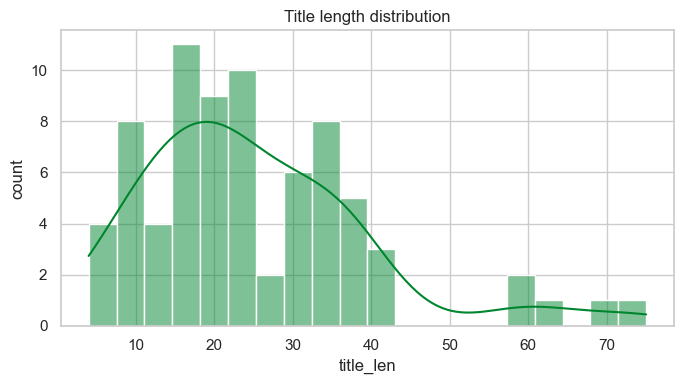

,count,mean,median,min,max
0,75,25.266667,22.0,4,75


In [15]:
# Histogram: title_len + display
vals = df["title_len"].dropna()

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, bins=20, kde=True)
ax.set_title("Title length distribution")
ax.set_xlabel("title_len")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": [int(vals.shape[0])], "mean": [vals.mean()], "median": [vals.median()], "min": [vals.min()], "max": [vals.max()]}))

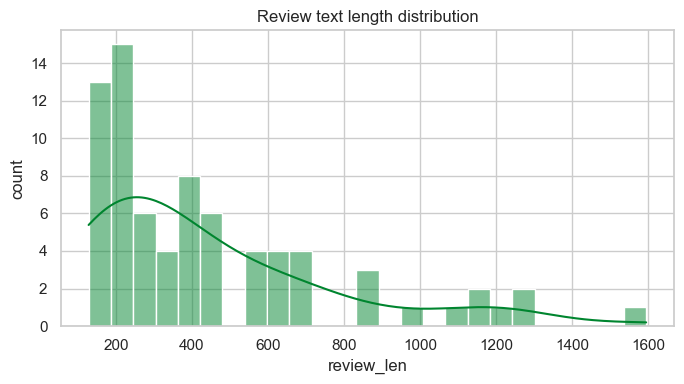

,count,mean,median,min,max
0,75,448.48,355.0,128,1595


In [16]:
# Histogram: review_len + display
vals = df["review_len"].dropna()

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, bins=25, kde=True)
ax.set_title("Review text length distribution")
ax.set_xlabel("review_len")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": [int(vals.shape[0])], "mean": [vals.mean()], "median": [vals.median()], "min": [vals.min()], "max": [vals.max()]}))

In [17]:
# Display + observation: average review length
vals = df["review_len"].dropna()
mean_len = vals.mean() if not vals.empty else np.nan
median_len = vals.median() if not vals.empty else np.nan

summary = pd.DataFrame(
    {
        "metric": ["mean review_len", "median review_len"],
        "value": [mean_len, median_len],
    }
)

display(summary)

print(
    "Observation: If the mean is noticeably higher than the median, the dataset likely has a tail of very long reviews (right-skew). "
    "If mean and median are close, lengths are more symmetric."
)

,metric,value
0,mean review_len,448.48
1,median review_len,355.00


Observation: If the mean is noticeably higher than the median, the dataset likely has a tail of very long reviews (right-skew). If mean and median are close, lengths are more symmetric.


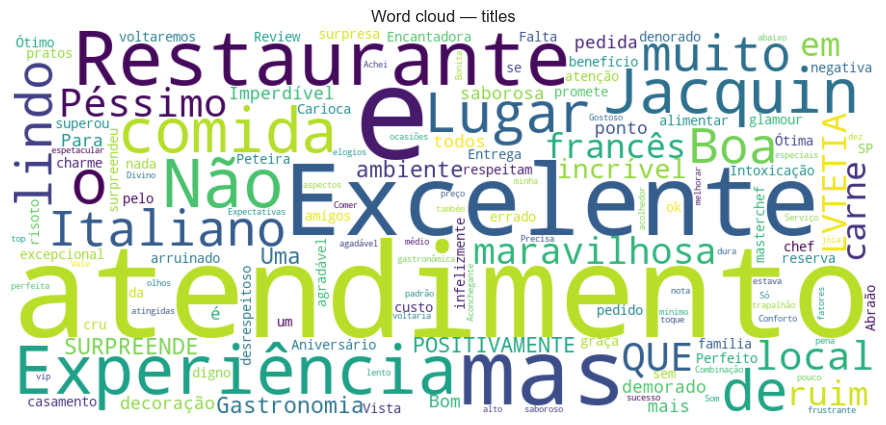

,title_wordcloud_source_chars
0,1969


In [22]:
# Word cloud: title (titulo)
text = " ".join(df["titulo"].dropna().astype(str).tolist())

if text.strip() == "":
    print("No title text available to build a word cloud.")
else:
    wc = WordCloud(width=900, height=400, background_color="white", stopwords=STOPWORDS).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word cloud — titles")
    plt.show()

    display(pd.DataFrame({"title_wordcloud_source_chars": [len(text)]}))

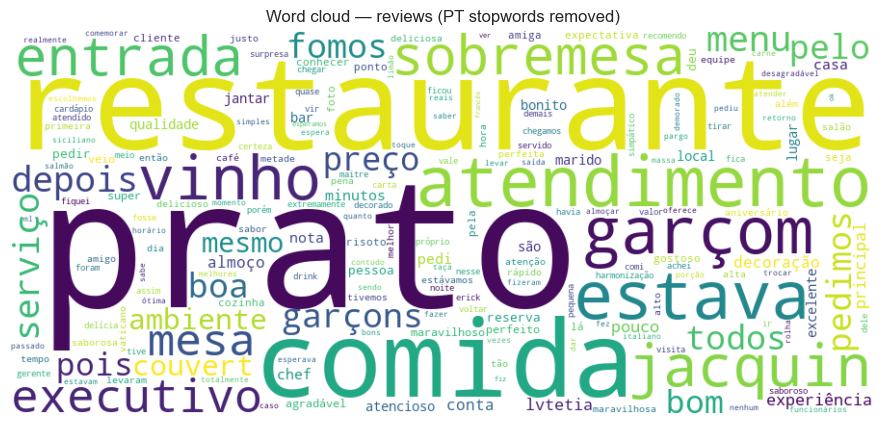

,review_wordcloud_source_chars
0,33710


In [31]:
# Word cloud: review text (review) — with Portuguese stop-words
text = " ".join(df["review"].dropna().astype(str).tolist())

# Common PT-BR stopwords (extend as needed)
pt_stopwords = {
    "a", "à", "ao", "aos", "as", "às", "o", "os", "um", "uma", "uns", "umas",
    "de", "da", "das", "do", "dos", "d", "dum", "duma",
    "e", "é", "em", "no", "nos", "na", "nas", "por", "para", "pra",
    "com", "sem", "sobre", "entre", "até", "desde", "após", "antes",
    "que", "quem", "quando", "onde", "como", "porque", "porquê", "por que",
    "se", "mas", "ou", "nem", "já", "ainda", "também", "muito", "muitos", "muita", "muitas",
    "mais", "menos", "bem", "mal", "só", "sim", "não",
    "eu", "me", "mim", "minha", "minhas", "meu", "meus",
    "você", "vocês", "te", "ti", "tua", "tuas", "teu", "teus",
    "ele", "ela", "eles", "elas", "lhe", "lhes", "seu", "seus", "sua", "suas",
    "nós", "nos", "nosso", "nossa", "nossos", "nossas",
    "um", "uma", "isso", "isto", "aquilo", "aqui", "aí", "ali",
    "este", "esta", "estes", "estas", "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",
    "tudo", "nada", "algo", "algum", "alguma", "alguns", "algumas",
    "cada", "qual", "quais", "outro", "outra", "outros", "outras",
    "ser", "estar", "ter", "tinha", "tem", "têm", "foi", "fui", "era", "eram", "sou", "está", "estão",
}

# Combine existing WordCloud stopwords (mostly EN) with PT stopwords
stopwords_all = set(STOPWORDS) | pt_stopwords

if text.strip() == "":
    print("No review text available to build a word cloud.")
else:
    wc = WordCloud(
        width=900,
        height=400,
        background_color="white",
        stopwords=stopwords_all,
        collocations=False,  # reduces bigrams like "muito bom"
    ).generate(text.lower())

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word cloud — reviews (PT stopwords removed)")
    plt.show()

    display(pd.DataFrame({"review_wordcloud_source_chars": [len(text)]}))

## 8) Correlations (Numeric Summary)
Finally, we compute a correlation matrix across engagement, ratings, time signals, and simple text-length features.

Note: We intentionally exclude direct correlations involving categorical encodings (like `em_companhia_de`) because the numeric codes are arbitrary and can be misleading.

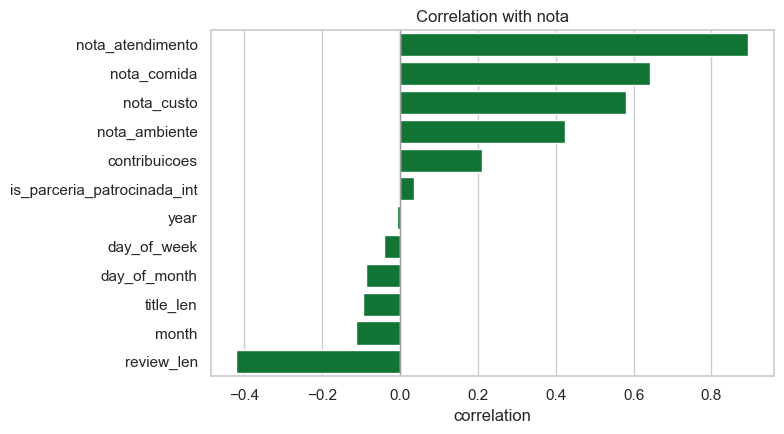

,feature,correlation_with_nota
0,nota_atendimento,0.895275
1,nota_comida,0.643540
2,nota_custo,0.580299
3,nota_ambiente,0.425114
4,contribuicoes,0.210113
5,is_parceria_patrocinada_int,0.036335
6,year,-0.006873
7,day_of_week,-0.041972
8,day_of_month,-0.087927
9,title_len,-0.095554


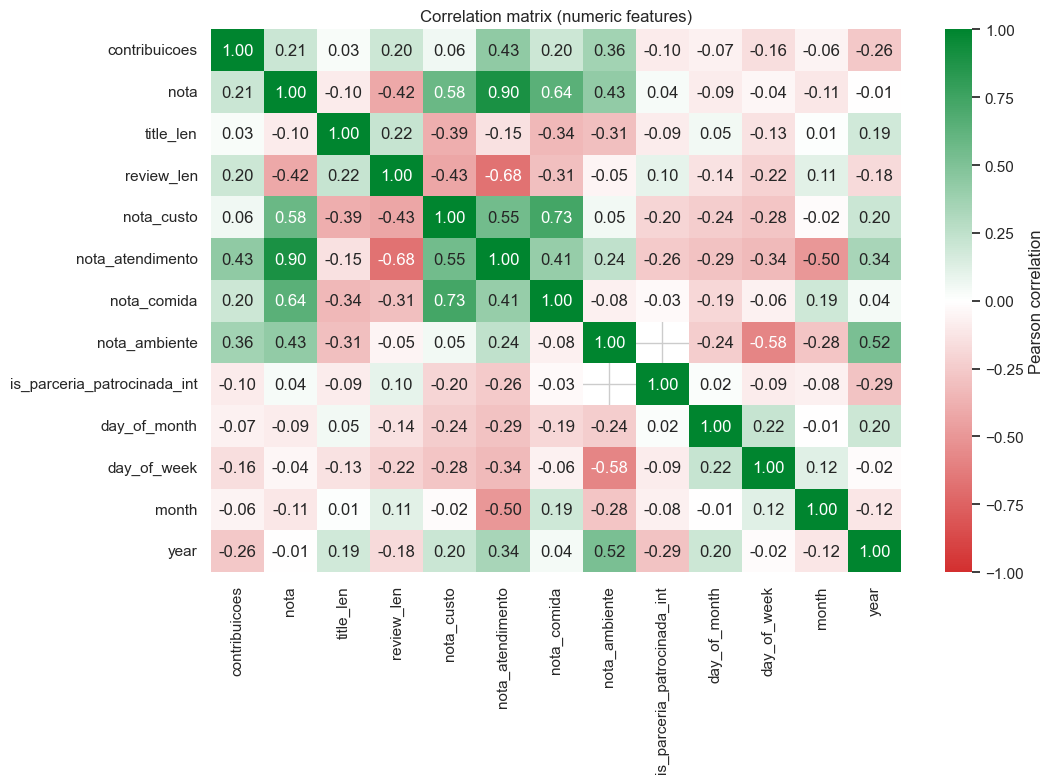

,feature_a,feature_b,correlation
0,nota,nota_atendimento,0.895275
1,nota_custo,nota_comida,0.728471
2,nota,nota_comida,0.643540
3,nota,nota_custo,0.580299
4,nota_custo,nota_atendimento,0.548945
5,nota_ambiente,year,0.517934
6,contribuicoes,nota_atendimento,0.434347
7,nota,nota_ambiente,0.425114
8,nota_atendimento,nota_comida,0.413055
9,contribuicoes,nota_ambiente,0.359883


In [5]:
from matplotlib.colors import LinearSegmentedColormap

# Correlation heatmap + sorted correlations vs nota (styled with DEFAULT_COLOR)

corr_cols = [
    "contribuicoes",
    "nota",
    "title_len",
    "review_len",
    "nota_custo",
    "nota_atendimento",
    "nota_comida",
    "nota_ambiente",
    "is_parceria_patrocinada_int",
    "day_of_month",
    "day_of_week",
    "month",
    "year",
]

# Keep only columns that actually exist to avoid KeyError
corr_cols = [c for c in corr_cols if c in df.columns]

corr_df = df[corr_cols].copy()
for c in corr_cols:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

corr = corr_df.corr()

# Ranked correlations vs the main target: nota
if "nota" in corr.columns:
    nota_corr = corr["nota"].drop(labels=["nota"]).sort_values(ascending=False)
else:
    nota_corr = pd.Series(dtype=float)

nota_corr_df = nota_corr.reset_index()
nota_corr_df.columns = ["feature", "correlation_with_nota"]

# 1) "Correlation with nota" graph
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=nota_corr_df,
    x="correlation_with_nota",
    y="feature",
    color=DEFAULT_COLOR,
)
ax.axvline(0, color="#9E9E9E", linewidth=1)
ax.set_title("Correlation with nota")
ax.set_xlabel("correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 2) feature and correlation_with_nota display
display(nota_corr_df)

# 3) correlation matrix
# Diverging colormap: negative=red, zero=white, positive=DEFAULT_COLOR
corr_cmap = LinearSegmentedColormap.from_list(
    "neg_white_pos_default",
    ["#D32F2F", "#FFFFFF", DEFAULT_COLOR],
    N=256,
)

plt.figure(figsize=(11, 8))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=corr_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

# 4) feature_a vs feature_b display
mask_upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(mask_upper).stack().sort_values(ascending=False)

pairs_df = pairs.reset_index()
pairs_df.columns = ["feature_a", "feature_b", "correlation"]

display(pairs_df)

## 9) Images
We finish by looking at the distribution of image counts per review.

C:\Users\Ayrton\AppData\Local\Temp\ipykernel_1868\301530587.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


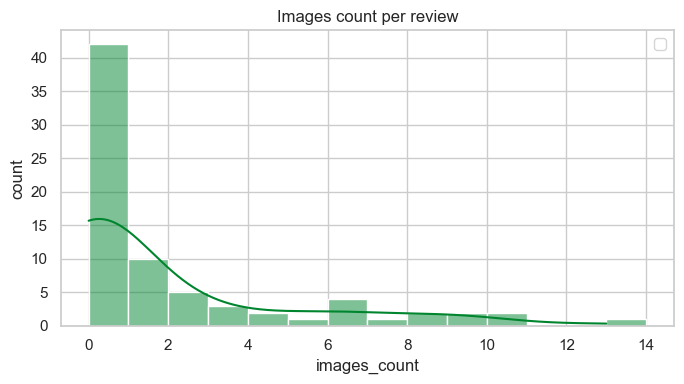

,count,mean,median,max,% with >=1
0,75,1.866667,0.0,13,44.0


In [19]:
# Histogram: images_count + display
vals = df["images_count"].fillna(0).astype(int)

plt.figure(figsize=(7, 4))
ax = sns.histplot(vals, kde=True, bins=range(int(vals.max()) + 2) if len(vals) else 10)
ax.legend()
ax.set_title("Images count per review")
ax.set_xlabel("images_count")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "count": [int(vals.shape[0])],
            "mean": [vals.mean()],
            "median": [vals.median()],
            "max": [vals.max()],
            "% with >=1": [(vals.gt(0).mean() * 100)],
        }
    )
)